In [ ]:
import pandas as pd
import pyarrow.parquet as pq
from glob import glob
import re
from tqdm import tqdm

path_pattern = "/work/hdd/bbjs/shared/corpora/vaani_iisc/Vaani/audio/**/*parquet"
metadata_path = "/work/hdd/bbjs/shared/corpora/vaani_iisc/Vaani/pincode_metadata.csv"

paths = glob(path_pattern, recursive=True)
print(f"Found {len(paths)} parquet files")

# Prepare pincode to lat/long mapping
# pin2latlong = pd.read_csv(metadata_path)[["Pincode", "Latitude", "Longitude"]]
# def to_float(x):
#     x = str(x).strip()
#     # extract the first float-like number (handles 72.7N, 12.9E, etc.)
#     m = re.search(r"([-+]?\d+(?:\.\d+)?)", x)
#     return float(m.group(1)) if m else None


# df = pd.read_csv(metadata_path).dropna(subset=["Pincode", "Latitude", "Longitude"])
# df["Pincode"] = df["Pincode"].astype(str).str.extract(r"(\d{6})")[0]
# df["Latitude"] = df["Latitude"].apply(to_float)
# df["Longitude"] = df["Longitude"].apply(to_float)
# df.dropna(inplace=True)

# pin2latlong = df.groupby("Pincode", as_index=False)[["Latitude", "Longitude"]].mean()
# print("Unique pincodes:", pin2latlong.shape)
# print(pin2latlong.head())

# pincodes = set()
# for idx, path in tqdm(enumerate(paths), total=len(paths)):
#     pf = pq.ParquetFile(path)
#     rg = pf.num_row_groups
#     for rg_idx in range(rg):
#         table = pf.read_row_group(rg_idx, columns=["pincode"])
#         pincodes.update(set(table["pincode"].to_pylist()))
# print("Unique pincodes in data:", len(pincodes))


# Explore a sample parquet file
# path = paths[0]
# pf = pq.ParquetFile(path)
# import torchaudio
# import io

# print("Schema:", pf.schema)
# print("Number of row groups:", pf.num_row_groups)
# relevant_columns = ["audio", "pincode"]

# for rg_idx in [0, 4]:
#     table = pf.read_row_group(rg_idx)
#     print(table.column_names, "column names")
#     row = {n: table[n][0].as_py() for n in relevant_columns}
#     print(len(row), row.keys())
#     audio = row["audio"]
#     pincode = row["pincode"]
#     print("Audio length (bytes):", len(audio))
#     print(type(audio), audio.keys())
#     b = audio["bytes"]
#     wav, sr = torchaudio.load(io.BytesIO(b))
#     print(wav.shape, sr)
#     print("Pincode:", pincode)
#     # save wav to file
#     out_wav_path = f"sample_rg{rg_idx}_pin{pincode}.wav"
#     torchaudio.save(out_wav_path, wav, sr)
#     break

Found 6470 parquet files
Schema: <pyarrow._parquet.ParquetSchema object at 0xfff34937edc0>
required group field_id=-1 schema {
  optional group field_id=-1 audio {
    optional binary field_id=-1 bytes;
    optional binary field_id=-1 path (String);
  }
  optional binary field_id=-1 language (String);
  optional binary field_id=-1 languagesKnown (String);
  optional binary field_id=-1 gender (String);
  optional binary field_id=-1 state (String);
  optional binary field_id=-1 district (String);
  optional int64 field_id=-1 pincode;
  optional binary field_id=-1 stay(years) (String);
  optional binary field_id=-1 isTranscriptionAvailable (String);
  optional binary field_id=-1 transcript (String);
  optional binary field_id=-1 referenceImage (String);
}

Number of row groups: 28
['audio', 'language', 'languagesKnown', 'gender', 'state', 'district', 'pincode', 'stay(years)', 'isTranscriptionAvailable', 'transcript', 'referenceImage'] column names
2 dict_keys(['audio', 'pincode'])
Audio l

In [2]:
import pandas as pd

vaani_metadata_path = "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.csv"
df = pd.read_csv(vaani_metadata_path)
df.dropna(inplace=True, subset=["latitude", "longitude", "audio_length"])
mask = (df["audio_length"] > 2) & (df["audio_length"] <= 10)
df = df[mask]
df

,parquet_path,row_group,row_index,pincode,latitude,longitude,audio_length
1,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,1,515531.0,14.112412,77.931085,5.998563
2,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,2,515561.0,14.014453,77.994101,4.259688
3,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,3,515123.0,14.091895,77.426874,7.048438
5,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,5,515661.0,14.517225,77.771846,4.346875
6,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,6,515711.0,14.300399,76.843286,8.951000
...,...,...,...,...,...,...,...
1369322,Vaani/audio/WestBengal/North24Parganas/train-0...,5,93,743297.0,23.187908,88.752621,5.103000
1369324,Vaani/audio/WestBengal/North24Parganas/train-0...,5,95,743297.0,23.187908,88.752621,4.016000
1369325,Vaani/audio/WestBengal/North24Parganas/train-0...,5,96,743297.0,23.187908,88.752621,7.611000
1369327,Vaani/audio/WestBengal/North24Parganas/train-0...,5,98,743297.0,23.187908,88.752621,7.775000


In [3]:
##########################################################################################
print("Unique pincodes in metadata:", df["pincode"].nunique())
##########################################################################################

from math import ceil
import numpy as np

# --- Config based on FLEURS-like proportions ---
TEST_FRAC = 0.05  # ≈ 5% total
VAL_FRAC = 0.05  # ≈ 5% total
MIN_TEST_PER_CLASS = 20
MIN_VAL_PER_CLASS = 20

SEED_TEST = 42
SEED_VAL = 43


def sample_balanced(g, frac, min_n, seed):
    """Sample by fraction but ensure at least min_n samples if available."""
    n = len(g)
    if n <= min_n:
        return g.sample(n=n // 3 if n > 2 else n, random_state=seed)
    k = min(n, max(min_n, ceil(frac * n)))
    return g.sample(n=k, random_state=seed)


# --- Test split ---
test_idx = (
    df.groupby("pincode", group_keys=False)
    .apply(lambda g: sample_balanced(g, TEST_FRAC, MIN_TEST_PER_CLASS, SEED_TEST))
    .index
)

remaining_idx = df.index.difference(test_idx)

# --- Validation split (from remaining) ---
val_idx = (
    df.loc[remaining_idx]
    .groupby("pincode", group_keys=False)
    .apply(lambda g: sample_balanced(g, VAL_FRAC, MIN_VAL_PER_CLASS, SEED_VAL))
    .index
)

train_idx = remaining_idx.difference(val_idx)

# --- Final sets ---
train_set = df.loc[train_idx]
val_set = df.loc[val_idx]
test_set = df.loc[test_idx]


# --- Reporting ---
def describe_split(name, subset):
    print(
        f"{name:>10}: {len(subset):>8} rows "
        f"({100*len(subset)/len(df):5.2f}% of total)"
    )


print(f"Total rows: {len(df):,}")
describe_split("Train", train_set)
describe_split("Validation", val_set)
describe_split("Test", test_set)
print("=" * 50)

Unique pincodes in metadata: 3934


/tmp/ipykernel_2101531/4050381607.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sample_balanced(g, TEST_FRAC, MIN_TEST_PER_CLASS, SEED_TEST))


Total rows: 1,171,036
     Train:   987119 rows (84.29% of total)
Validation:    87271 rows ( 7.45% of total)
      Test:    96646 rows ( 8.25% of total)


/tmp/ipykernel_2101531/4050381607.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sample_balanced(g, VAL_FRAC, MIN_VAL_PER_CLASS, SEED_VAL))


In [4]:
train_set.audio_length.sum() / 3600, val_set.audio_length.sum() / 3600, test_set.audio_length.sum() / 3600

(np.float64(1311.152953107639),
 np.float64(122.36630956597222),
 np.float64(136.73608835069444))

In [52]:
import pandas as pd
from pathlib import Path

# --- config ---
SUBFRACS = [0.10, 0.20, 0.40, 0.60, 1.00]
TRAIN_SEED = 123
LABEL = "pincode"

# Base output directory
base_output = Path(
    "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local"
)
base_output.mkdir(parents=True, exist_ok=True)

# 1) Shuffle train_set within each class ONCE -> nested subsets
shuffled_train = (
    train_set.groupby(LABEL, group_keys=True)
    .apply(lambda g: g.sample(frac=1.0, random_state=TRAIN_SEED))
    .reset_index(level=0, drop=True)
)


def take_frac_nested(shuff: pd.DataFrame, label_col: str, frac: float) -> pd.DataFrame:
    """Take the first k items per class from a single global shuffle -> nested subsets."""
    sizes = shuff.groupby(label_col).size()
    # ensure at least 1 sample per class if present in train
    k_per_class = (sizes * frac).astype(int).clip(lower=(1 if frac > 0 else 0))
    return shuff.groupby(label_col, group_keys=False).apply(
        lambda g: g.head(k_per_class.get(g.name, 0))
    )


# 2) Prepare fixed val/test frames (same for every file)
val_out = val_set.copy()
val_out["split"] = "val"
test_out = test_set.copy()
test_out["split"] = "test"

# 3) For each fraction, write a CSV that includes train subset + val + test
for f in SUBFRACS:
    train_sub = take_frac_nested(shuffled_train, LABEL, f).copy()
    train_sub["split"] = "train"

    combined = pd.concat([train_sub, val_out, test_out], axis=0)
    pct = int(f * 100)
    out_path = base_output / f"vaani_geolocation_metadata.train{pct}.csv"
    combined.to_csv(out_path, index=False)

    # simple report
    n_train = (combined["split"] == "train").sum()
    n_val = (combined["split"] == "val").sum()
    n_test = (combined["split"] == "test").sum()
    print(
        f"[train{pct}] -> {out_path} | train={n_train:,}  val={n_val:,}  test={n_test:,}  total={len(combined):,}"
    )

/tmp/ipykernel_2108743/605079221.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=1.0, random_state=TRAIN_SEED))
/tmp/ipykernel_2108743/605079221.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return shuff.groupby(label_col, group_keys=False).apply(


[train10] -> /work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.train10.csv | train=97,694  val=87,271  test=96,646  total=281,611


/tmp/ipykernel_2108743/605079221.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return shuff.groupby(label_col, group_keys=False).apply(


[train20] -> /work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.train20.csv | train=196,151  val=87,271  test=96,646  total=380,068


/tmp/ipykernel_2108743/605079221.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return shuff.groupby(label_col, group_keys=False).apply(


[train40] -> /work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.train40.csv | train=393,396  val=87,271  test=96,646  total=577,313


/tmp/ipykernel_2108743/605079221.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return shuff.groupby(label_col, group_keys=False).apply(


[train60] -> /work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.train60.csv | train=590,744  val=87,271  test=96,646  total=774,661


/tmp/ipykernel_2108743/605079221.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return shuff.groupby(label_col, group_keys=False).apply(


[train100] -> /work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.train100.csv | train=987,119  val=87,271  test=96,646  total=1,171,036


In [40]:
output_path = "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/src/recipe/geolocation/local/vaani_geolocation_metadata.withsplits.csv"
# combine train, val, test sets and save to csv
final_df = pd.concat(
    [
        train_set.assign(split="train"),
        val_set.assign(split="val"),
        test_set.assign(split="test"),
    ]
)

final_df.to_csv(output_path, index=False)
final_df

,parquet_path,row_group,row_index,pincode,latitude,longitude,audio_length,split
3,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,3,515123.0,14.091895,77.426874,7.048438,train
5,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,5,515661.0,14.517225,77.771846,4.346875,train
8,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,8,515787.0,14.479429,77.220920,3.304187,train
9,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,9,515501.0,14.232323,78.069871,2.640625,train
10,Vaani/audio/AndhraPradesh/Anantpur/train-00047...,9,10,515865.0,14.855708,76.604364,4.383000,train
...,...,...,...,...,...,...,...,...
214961,Vaani/audio/Bihar/Kishanganj/train-00005-of-00...,1,87,855117.0,25.678160,86.941143,4.725313,test
227096,Vaani/audio/Bihar/Kishanganj/train-00012-of-00...,1,92,855117.0,25.678160,86.941143,2.261312,test
214957,Vaani/audio/Bihar/Kishanganj/train-00005-of-00...,1,83,855117.0,25.678160,86.941143,8.874688,test
214965,Vaani/audio/Bihar/Kishanganj/train-00005-of-00...,1,91,855117.0,25.678160,86.941143,6.880000,test


In [1]:
train_set

NameError: name 'train_set' is not defined

<Axes: >

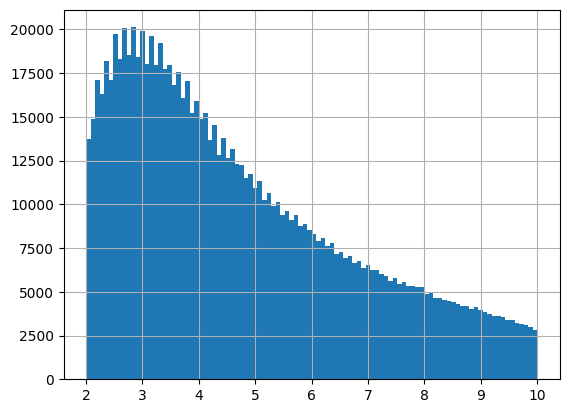

In [49]:
train_set.audio_length.hist(bins=100)

<Axes: >

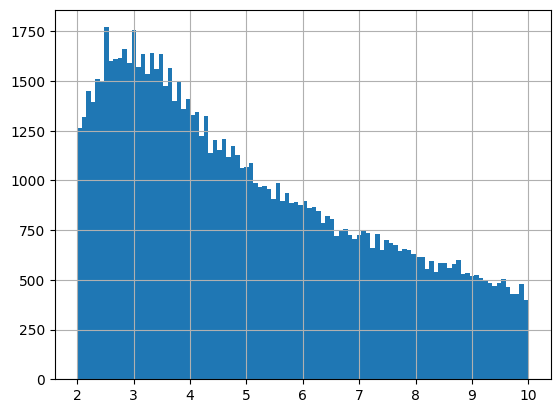

In [50]:
test_set.audio_length.hist(bins=100)

<Axes: >

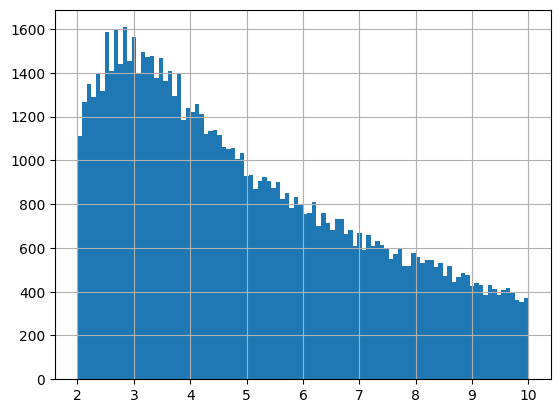

In [51]:
val_set.audio_length.hist(bins=100)

In [ ]:
def sec_to_hr(seconds):
    return seconds / 3600

np.float64(1272.183805190972)